In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ev_verisi = pd.read_csv('/content/drive/MyDrive/proje_ev_fiyatlari.csv')
musteri_verisi = pd.read_csv('/content/drive/MyDrive/proje_musteri_segmentasyonu.csv')

print("EV VERİSİ")
display(ev_verisi.head())

print("MÜŞTERİ VERİSİ")
display(musteri_verisi.head())

EV VERİSİ


,alan,oda_sayisi,bina_yasi,merkeze_uzaklik,kat,fiyat
0,103.1,3,34.7,6.6,2,2399.0
1,192.4,5,19.5,4.4,4,4023.0
2,158.5,5,35.8,21.9,8,2928.0
3,137.8,3,32.0,5.9,11,2860.0
4,69.2,2,17.0,24.4,13,1913.0


MÜŞTERİ VERİSİ


,yillik_gelir,harcama_puani
0,100077.0,79.4
1,120174.0,21.8
2,112921.0,79.5
3,117416.0,76.9
4,18731.0,79.8


In [ ]:
X = ev_verisi[['alan', 'oda_sayisi', 'bina_yasi', 'merkeze_uzaklik', 'kat']]
y = ev_verisi['fiyat']
print("X boyut:", X.shape)
print("y boyut", y.shape)

display(X.head())
display(y.head())

X boyut: (400, 5)
y boyut (400,)


,alan,oda_sayisi,bina_yasi,merkeze_uzaklik,kat
0,103.1,3,34.7,6.6,2
1,192.4,5,19.5,4.4,4
2,158.5,5,35.8,21.9,8
3,137.8,3,32.0,5.9,11
4,69.2,2,17.0,24.4,13


,fiyat
0,2399.0
1,4023.0
2,2928.0
3,2860.0
4,1913.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (320, 5)
X_test: (80, 5)
y_train: (320,)
y_test: (80,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled boyutu:", X_train_scaled.shape)
print("X_test_scaled boyutu:", X_test_scaled.shape)

X_train_scaled boyutu: (320, 5)
X_test_scaled boyutu: (80, 5)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MSE:", mse_linear)
print("R2:", r2_linear)

Linear Regression
MSE: 43795.587333452655
R2: 0.9114197692302688


In [ ]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MSE:", mse_ridge)
print("R2:", r2_ridge)

Ridge Regression
MSE: 43846.33137827444
R2: 0.9113171351642776


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pcr_model = LinearRegression()
pcr_model.fit(X_train_pca, y_train)
y_pred_pcr = pcr_model.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)
r2_pcr = r2_score(y_test, y_pred_pcr)

print("PCR ")
print("MSE:", mse_pcr)
print("R2:", r2_pcr)

PCR 
MSE: 138874.3603697212
R2: 0.7191150150382302


In [ ]:
from sklearn.cross_decomposition import PLSRegression
pls_model = PLSRegression(n_components=3)
pls_model.fit(X_train_scaled, y_train)
y_pred_pls = pls_model.predict(X_test_scaled).ravel()
mse_pls = mean_squared_error(y_test, y_pred_pls)
r2_pls = r2_score(y_test, y_pred_pls)
print("PLS Regression")
print("MSE:", mse_pls)
print("R2:", r2_pls)

PLS Regression
MSE: 50872.84328723106
R2: 0.8971054283623409


In [ ]:
from sklearn.neural_network import MLPRegressor
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', random_state=42, max_iter=2000)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Regression")
print("MSE:", mse_mlp)
print("R2:", r2_mlp)

MLP Regression
MSE: 29430.918974576663
R2: 0.9404735099295736


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
sonuclar_regresyon = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'PCR',
        'PLS Regression',
        'MLP Regression'
    ],
    'MSE': [
        mse_linear,
        mse_ridge,
        mse_pcr,
        mse_pls,
        mse_mlp
    ],
    'R2': [
        r2_linear,
        r2_ridge,
        r2_pcr,
        r2_pls,
        r2_mlp
    ]
})

display(sonuclar_regresyon)

# en düşük MSE ve en yüksek R^2 değerlerini MLP verdiği için en başarılı model diyebiliriz.
# en zayıf model ise PCR diyebiliriz.
# PLS ise PCR den daha başarılı ama Lineardan daha kötü
# Ringe ise Lineara çok yakın bir başarıda

,Model,MSE,R2
0,Linear Regression,43795.587333,0.911420
1,Ridge Regression,43846.331378,0.911317
2,PCR,138874.360370,0.719115
3,PLS Regression,50872.843287,0.897105
4,MLP Regression,29430.918975,0.940474


In [ ]:
X_kume = musteri_verisi[['yillik_gelir', 'harcama_puani']]

print("Kümeleme verisi boyutu:", X_kume.shape)
display(X_kume.head())

Kümeleme verisi boyutu: (300, 2)


,yillik_gelir,harcama_puani
0,100077.0,79.4
1,120174.0,21.8
2,112921.0,79.5
3,117416.0,76.9
4,18731.0,79.8


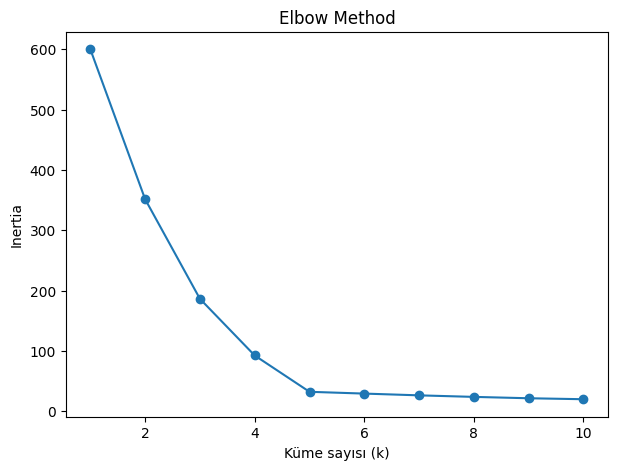

Küme sayısı: 5
Silhouette Score: 0.7150796512747705


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_kume_scaled)
  inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Küme sayısı (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kume_etiketi = kmeans_final.fit_predict(X_kume_scaled)

silhouette = silhouette_score(X_kume_scaled, kume_etiketi)
print("Küme sayısı:", 5)
print("Silhouette Score:", silhouette)

In [ ]:
# Elbow grafiğinde kırılma noktası K=5 civarında görülmekte Bu nedenle müşteri segmentasyonu için 5 küme seçilmiştir.

In [ ]:
#Grafik müşterilerin gelir ve harcama puanlarına göre 5 farklı gruba ayırmış. Silhouette skorunun 0.7151 olması da kümelemenin başarılı olduğunu gösterir.

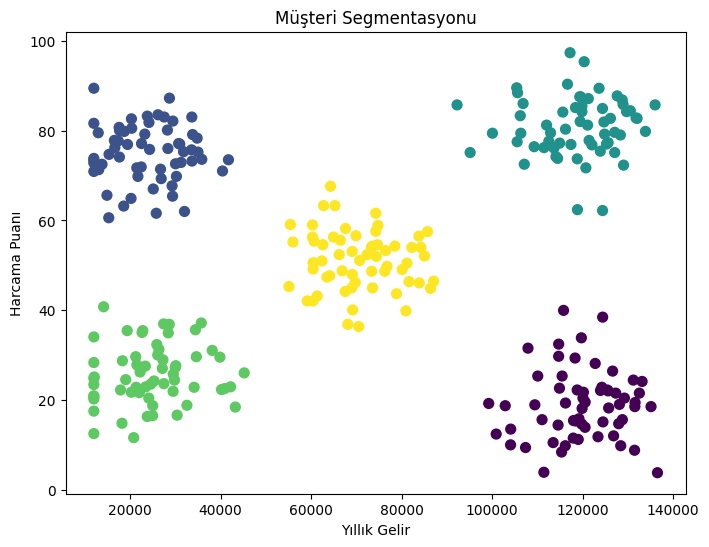

In [ ]:
musteri_verisi['kume'] = kume_etiketi
plt.figure(figsize=(8,6))
plt.scatter(musteri_verisi['yillik_gelir'], musteri_verisi['harcama_puani'], c=musteri_verisi['kume'], s=50)
plt.xlabel('Yıllık Gelir')
plt.ylabel('Harcama Puanı')
plt.title('Müşteri Segmentasyonu')
plt.show()

In [ ]:
kume_ozet = musteri_verisi.groupby('kume').agg({
    'yillik_gelir': 'mean',
    'harcama_puani': 'mean'
})

display(kume_ozet)

,yillik_gelir,harcama_puani
kume,,
0,119952.383333,18.975000
1,23898.250000,74.910000
2,118735.666667,80.858333
3,25038.666667,25.716667
4,70796.216667,51.130000


In [ ]:
# kümeler genel olarak iyi ayrıldı
# küme 0 yüksek gelir - düşük harcama
# küme 1 düşük gelir - yüksek harcama
# küme 2 yüksek gelir - yüksek harcama
# küme 3 düşük gelir - düşük harcama
# küme 4 orta gelir - orta harcama

In [ ]:
!pip install -q kagglehub[pandas-dataset]
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "IMDB Dataset.csv"

imdb_verisi = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
    file_path
)

display(imdb_verisi.head())
print(imdb_verisi.shape)

/tmp/ipykernel_1584/1609129284.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  imdb_verisi = kagglehub.load_dataset(


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


(50000, 2)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
X_text = imdb_verisi['review']
y_text = imdb_verisi['sentiment'].map({
    'positive': 1,
    'negative': 0
})
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(X_text, y_text, test_size=0.2, random_state=42)

print("Eğitim:", X_train_text.shape)
print("Test:", X_test_text.shape)

Eğitim: (40000,)
Test: (10000,)


In [ ]:
max_words = 10000
map_len = 200
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)
X_train_pad = pad_sequences(X_train_seq, maxlen=map_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=map_len)

print("X_train_pad:", X_train_pad.shape)
print("X_test_pad:", X_test_pad.shape)


X_train_pad: (40000, 200)
X_test_pad: (10000, 200)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=32),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = rnn_model.fit(
    X_train_pad,
    y_train_text,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.7150 - loss: 0.5255 - val_accuracy: 0.8289 - val_loss: 0.4049
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.8477 - loss: 0.3558 - val_accuracy: 0.7374 - val_loss: 0.5237
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.8648 - loss: 0.3240 - val_accuracy: 0.7809 - val_loss: 0.4641
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.9016 - loss: 0.2506 - val_accuracy: 0.8487 - val_loss: 0.3732
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9326 - loss: 0.1857 - val_accuracy: 0.8410 - val_loss: 0.3731


In [ ]:
loss_rnn, acc_rnn = rnn_model.evaluate(X_test_pad, y_test_text)
print("RNN Loss:", loss_rnn)
print("RNN Accuracy:", acc_rnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8481 - loss: 0.3626
RNN Loss: 0.3625722825527191
RNN Accuracy: 0.8481000065803528


In [ ]:
#model test yorumlarının yaklaşı %84ü doğru sınıflandırıyorr

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(X_train_img, y_train_img), (X_test_img, y_test_img) = fashion_mnist.load_data()

X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

print("Eğitim:", X_train_img.shape)
print("Test:", X_test_img.shape)

Eğitim: (60000, 28, 28)
Test: (10000, 28, 28)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = cnn_model.fit(
    X_train_img,
    y_train_img,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 116ms/step - accuracy: 0.8359 - loss: 0.4611 - val_accuracy: 0.8778 - val_loss: 0.3393
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 103s 64ms/step - accuracy: 0.8915 - loss: 0.2997 - val_accuracy: 0.8932 - val_loss: 0.2905
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.9096 - loss: 0.2521 - val_accuracy: 0.9059 - val_loss: 0.2597
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.9192 - loss: 0.2188 - val_accuracy: 0.9093 - val_loss: 0.2500
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 66ms/step - accuracy: 0.9308 - loss: 0.1917 - val_accuracy: 0.9111 - val_loss: 0.2526


In [ ]:
loss_cnn, acc_cnn = cnn_model.evaluate(
    np.expand_dims(X_test_img, axis=-1) if X_test_img.ndim == 3 else X_test_img,
    y_test_img,
    verbose=1
)

print("CNN Test Loss:", loss_cnn)
print("CNN Test Accuracy:", acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9045 - loss: 0.2632
CNN Test Loss: 0.2631915509700775
CNN Test Accuracy: 0.9045000076293945


In [ ]:
# model görüntülerin %90ı doğru sınıflandırabiliyor

In [ ]:
with open('/content/drive/MyDrive/sonuclar.txt', 'w') as dosya:
    dosya.write(f"Regresyon en iyi R2: {r2_mlp:.4f}\n")
    dosya.write(f"Kumeleme silhouette: {silhouette:.4f}\n")
    dosya.write(f"RNN accuracy: {acc_rnn:.4f}\n")
    dosya.write(f"CNN accuracy: {acc_cnn:.4f}\n")

In [ ]:
with open('/content/drive/MyDrive/sonuclar.txt', 'r', encoding='utf-8') as dosya:
    print(dosya.read())

Regresyon en iyi R2: 0.9405
Kumeleme silhouette: 0.7151
RNN accuracy: 0.8481
CNN accuracy: 0.9045



In [ ]:
def regresyon():
    print("Regresyon Analizi")
    print("Linear R2:", round(r2_linear, 4))
    print("Ridge R2:", round(r2_ridge, 4))
    print("PCR R2:", round(r2_pcr, 4))
    print("PLS R2:", round(r2_pls, 4))
    print("MLP R2:", round(r2_mlp, 4))

def kumeleme():
    print("Kümeleme Analizi")
    print("Küme sayısı: 5")
    print("Silhouette:", round(silhouette, 4))

def duygu():
    print("Duygu Analizi")
    print("RNN Accuracy:", round(acc_rnn, 4))

def goruntu():
    print("Görüntü Sınıflandırma")
    print("CNN Accuracy:", round(acc_cnn, 4))

while True:
    print("\n1- Regresyon")
    print("2- Kümeleme")
    print("3- Duygu Analizi")
    print("4- Görüntü Sınıflandırma")
    print("5- Çıkış")

    secim = input("Seçim: ")

    if secim == "1":
        regresyon()
    elif secim == "2":
        kumeleme()
    elif secim == "3":
        duygu()
    elif secim == "4":
        goruntu()
    elif secim == "5":
        break
    else:
        print("Hatalı seçim")


1- Regresyon
2- Kümeleme
3- Duygu Analizi
4- Görüntü Sınıflandırma
5- Çıkış
Seçim: 1
Regresyon Analizi
Linear R2: 0.9114
Ridge R2: 0.9113
PCR R2: 0.7191
PLS R2: 0.8971
MLP R2: 0.9405

1- Regresyon
2- Kümeleme
3- Duygu Analizi
4- Görüntü Sınıflandırma
5- Çıkış
Seçim: 5
